# Lab 4

In this lab, you will be working with pretrained neural networks to perform predictions as well as fine-tune those models for different datasets. We suggest that you use google colab to work with the notebook.

In [36]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## PART 1: Using pretrained Neural Networks

There exist many different models that have been trained on a vast amount of data, removing the need for you to train your own models from scratch. Another advantage of using these models is the fact that they may have been trained on data that is similar to your data, thus they already have a good idea about what is important to make good predictions.

Here is an example how we could use a pretrained model to make predictions.
Fill in the missing parts to make this example work (YOUR DON'T NEED TO REPORT THIS IN THE REPORT)

In [37]:
model = ResNet50(weights='imagenet')

#Test it out, upload an image to colab and specify the path to the image here
img_path = "shark.jpg"


#We need to load the image we want to classify with the right input size.
#Here ResNet50 need a size of 224x224
#Load the image in the right size, fill in target_size with the correct dimensions
img = image.load_img(img_path, target_size=(224, 224))

#some preprocessing
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

#predict
preds = model.predict(x)
# decode the results into a list of tuples (class, description, probability)
# (one such list for each sample in the batch)
#use the decode_predictions function we have imported, show the top five predictions
print('Predicted:', decode_predictions(preds, top=5)[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: [('n01484850', 'great_white_shark', np.float32(0.4167522)), ('n02641379', 'gar', np.float32(0.24085632)), ('n02536864', 'coho', np.float32(0.09843042)), ('n02066245', 'grey_whale', np.float32(0.06992667)), ('n02640242', 'sturgeon', np.float32(0.05660361))]


In [38]:
# tensorflow.keras has CIFAR100 available. You can load it by using cifar100 = tf.keras.datasets.cifar100
# When using the load_data() function on the object you just loaded, it will return two tuples (X_train, Y_train), (X_test, Y_test)
(X_train,Y_train) , (X_test,Y_test) = tf.keras.datasets.cifar100.load_data(label_mode='fine')


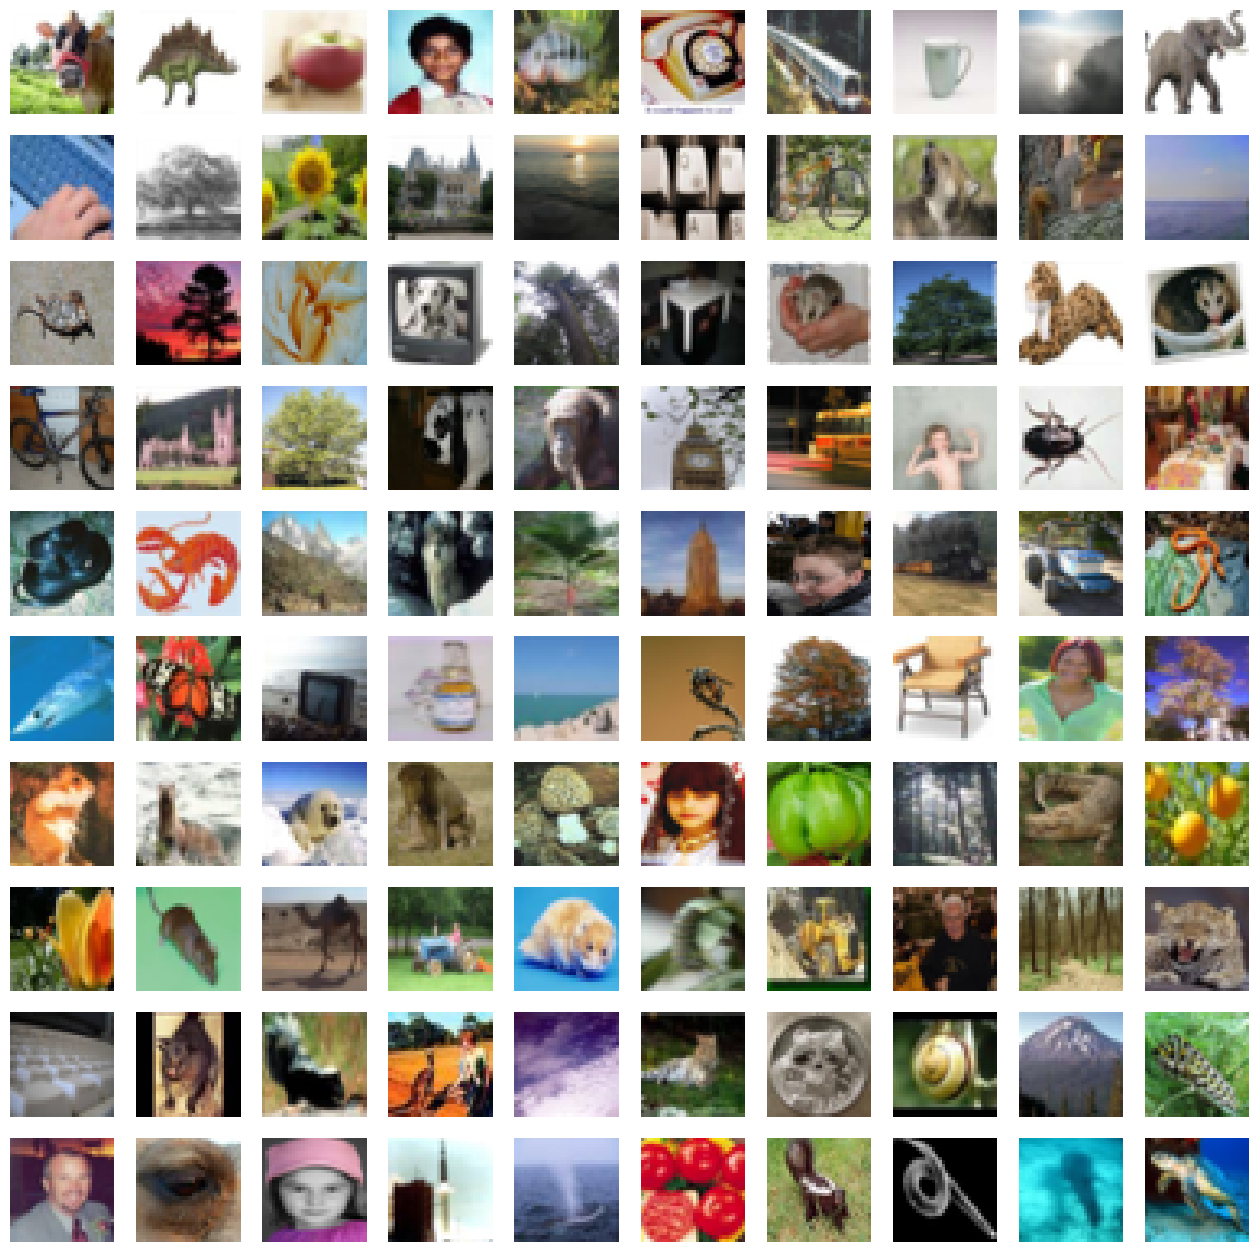

In [39]:
#Test if the load was successful by plotting some of the images:
plt.figure(figsize = (16,16))
for i in range(100):
  plt.subplot(10,10,1+i)
  plt.axis('off')
  plt.imshow(X_train[i], cmap = 'gray')

# Task 1

Your task is now to load a random subset of 100 images in the CIFAR100 dataset and run predictions using different pretrained networks. Choose 5 classes and select 20 images for each class. Choose 5 different pretrained networks of your liking. Make sure that the weights you load for each network are not trained on the CIFAR100 dataset. For example always specify weights="imagenet".

You need to report this mapping in your report.

Classify the 100 images ((20 images x 5 classes) and take the top 1 of results as the prediction. Compute the average accuracy for each model on the 100 images per class and report the results. Note that the classes between imagenet and CIFAR100 are different. Match the 5 classes in CIFAR100 to similar Imagenet classes! This requires that you look at the dataset descriptions.

For CIFAR100, you can use huggingface as a quick reference for extracting the fine labels: https://huggingface.co/datasets/uoft-cs/cifar100

For imagenet, one can use the mapping provided here: https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/

The end result should look like a table with each network in the row
and the average accuracy for each class in the columns. (PUT THIS IN THE REPORT)

| Network | Class 1 | Class2 | Class3 | Class4 | Class5
| --- | --- | --- |---| --- | --- |
| Network 1 | 95% | 97% | ...
| Network 2 | 90% | 98% | ...
| Network 3 | 91% | 94% | ...
| Network 4 | ...
| Network 5 | ...

# Task 1.1 Define a class mapping from CIFAR100 to similar ImageNet classes.


- Fill in the appropriate classes. You need to look at the dataset descriptions to find the corresponding class name.
Why do this? This needs to be done since a model trained on imagenet might return class label 234 "Rottweiler", which is similar to
CIFAR100 class 97 "Wolf". The model might predict the correct label,
but returning 234 as a label does not even exist in CIFAR100.
Your task is to select 5 classes in CIFAR100 and find the similar
classes in Imagenet. If a model predicts for example 234, you need to
translate this to class 97. Do this for all 5 classes. (PUT THIS IN THE REPORT)
- Using np.argmax(predictions, axis=-1) will return the top 1 class labels for
imagenet. Note, it is possible that there are several similar classes in
imagenet that could fit one class in CIFAR100. For this exercise, you should
just one class for now, even though this might reduce the accuracy.

In [7]:
class_mapping = {
    820: 90,  # Steam locomotive → train
    386: 31,  # African elephant → elephant
    945: 83,  # Bell pepper → sweet_pepper
    361: 75,  # Skunk → skunk
    508: 39,  # Computer keyboard → keyboard
}

# You can then use the dictionary to translate the output of the pretrained
# network into the CIFAR100 class and compute average accuracy afterwards

# Function to select images from specified classes. You just have to use this
# function to get the images from the CIFAR100 dataset for testing the
# networks
# You just need to specify what class label you want (example: 97) and how many
# images of that class

def select_images_by_classes(X_test, Y_test, class_indices, num_images_per_class=20):
    selected_images = []
    selected_labels = []
    for class_idx in class_indices:
        class_images = X_test[Y_test.flatten() == class_idx][:num_images_per_class]
        selected_images.extend(class_images)
        selected_labels.extend([class_idx] * num_images_per_class)
    return np.array(selected_images), np.array(selected_labels)

# Select 100 images (20 from each of the 5 classes)
selected_class_indices = [820, 386, 945, 361, 508]
selected_images, selected_labels = select_images_by_classes(X_test, Y_test, selected_class_indices)

#Task 1.2 (DON'T PUT THIS IN THE REPORT)

In [8]:
# Define a function that takes a list of predicted labels and the true labels,
#  remember you can use numpy.mean() to compute the average of a binary vector.
# the binary vector cann be created by comparing reach row of y_pred with the row
# in y_true using "=="

def avg_accuracy(y_pred, y_true):
    return np.mean(y_pred == y_true)

# For a set of images of a specific class, you can call this function to compute
# the accuracy of the network on that class. You can then do this for all 5 classes.



# Your pipeline may look like this:

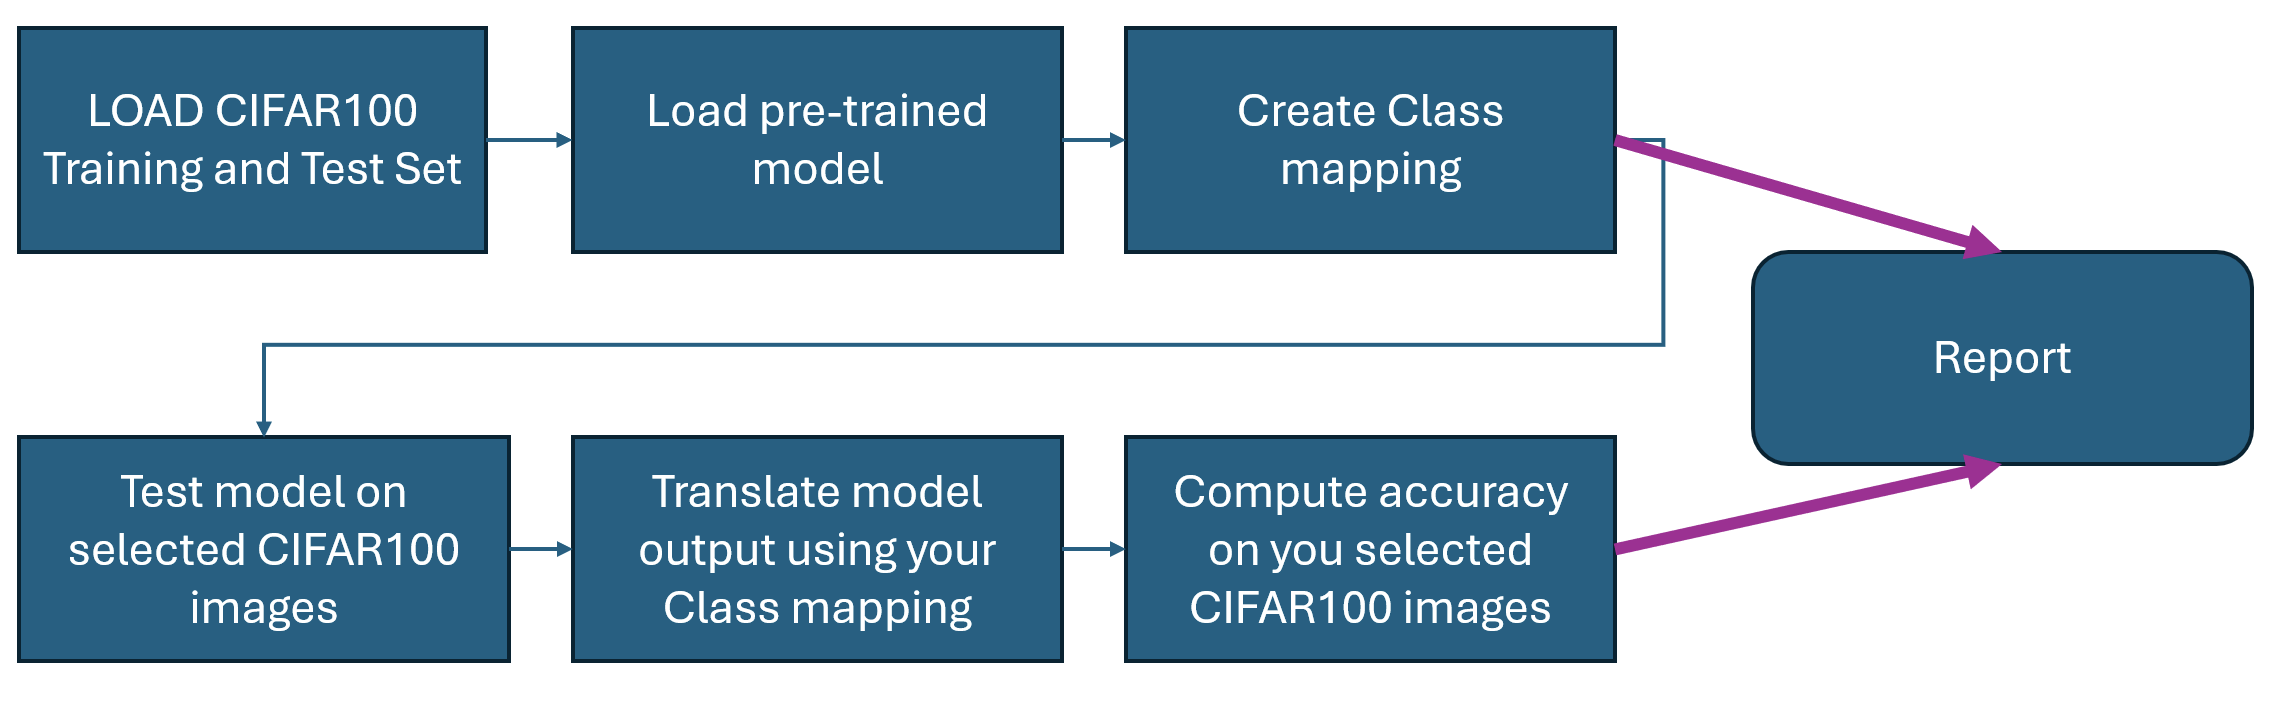

# Model Fine Tuning and Transfer Learning

While we have used pretrained models to do predictions, you may already have seen that using these models will result in worse performance when using data similar but not identical data the model has been trained on. To overcome this limitation, we can fine-tune existing models to the data we are interested in classifying.

This works rather well since all the pretained models have one thing in common: They have been trained on image data. This results in unique "filters" in the model neurons that are quite similar between different datasets. Especially the first couple of layers in the network have universal primitive filters, like edge detectors and corner detectors. Only in the later layers of the network do we have neurons that are more specialized to the specific dataset.

This is especially useful if you do not have much data to train a large network, but you may yet have enough to fine-tune an existing model. This may performs much better than a smaller model trained on limited data from scratch!

Let us use this fact and fine-tune a model to make better prediction.
Fist lets load the cast and dogs dataset



In [11]:
!pip install -q kaggle
!kaggle datasets download -d birajsth/cats-and-dogs-filtered -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/birajsth/cats-and-dogs-filtered
License(s): unknown
100%|███████████████████████████████████████| 131M/131M [00:05<00:00, 24.6MB/s]



After that, unzip the dataset and set the path to the training and validation set.

In [17]:
import os
import zipfile

# with zipfile.ZipFile('./data/cats-and-dogs-filtered.zip', 'r') as zip_ref:
#     zip_ref.extractall('./data/')

base_dir = './data/cats_and_dogs_filtered/'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

## Loading the dataset from a directory

Let’s now load the images from their location. The `image_dataset_from_directory` function can be used because it can infer class labels.

The function will create a `tf.data.Dataset` from the directory.

Import the required modules and load the training and validation set.

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image_dataset_from_directory

training_set = image_dataset_from_directory(train_dir,
                                             shuffle=True,
                                             batch_size=32,
                                             image_size=(150, 150))

val_dataset = image_dataset_from_directory(validation_dir,
                                                  shuffle=True,
                                                  batch_size=32,
                                                  image_size=(150, 150))

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


## Data pre-processing

Whereas data pre-processing isn’t a specific step in transfer learning, it is an important step in training machine learning models in general. Let’s, therefore, apply some augmentation to the images we want to finetune on. Applying augmentation to a training set reduces overfitting the model to the training set, because it exposes the model to different aspects of each image.

You especially want to augment the data when there aren't much data available for training. You can augment it using various transformations, like:

    random rotations,
    horizontal flipping,
    zooming,
    shearing.

More details on augmentations can be found here: https://keras.io/api/layers/preprocessing_layers/image_augmentation/

You can apply these transformations when loading the data. Alternatively, as you can see below, you can augment by introducing unique layers you can attach to an existing model

In [19]:
data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
    ]
)

These layers will only be applied during the training process.

You can see the result of the above transformations by applying the layers to the same image. Here’s the code:

Image Shape: (150, 150, 3)


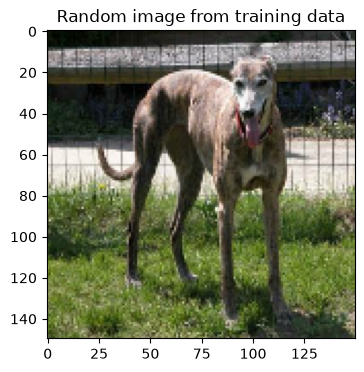

In [20]:
import numpy as np
import matplotlib.pyplot as plt

for images, labels in training_set.take(1):
    first_image = images[0]

print("Image Shape:", first_image.shape)

# Plot tthe original image first.
plt.figure(figsize=(4, 4))
plt.imshow(first_image.numpy().astype("uint8"))
plt.title("Random image from training data")
plt.show()

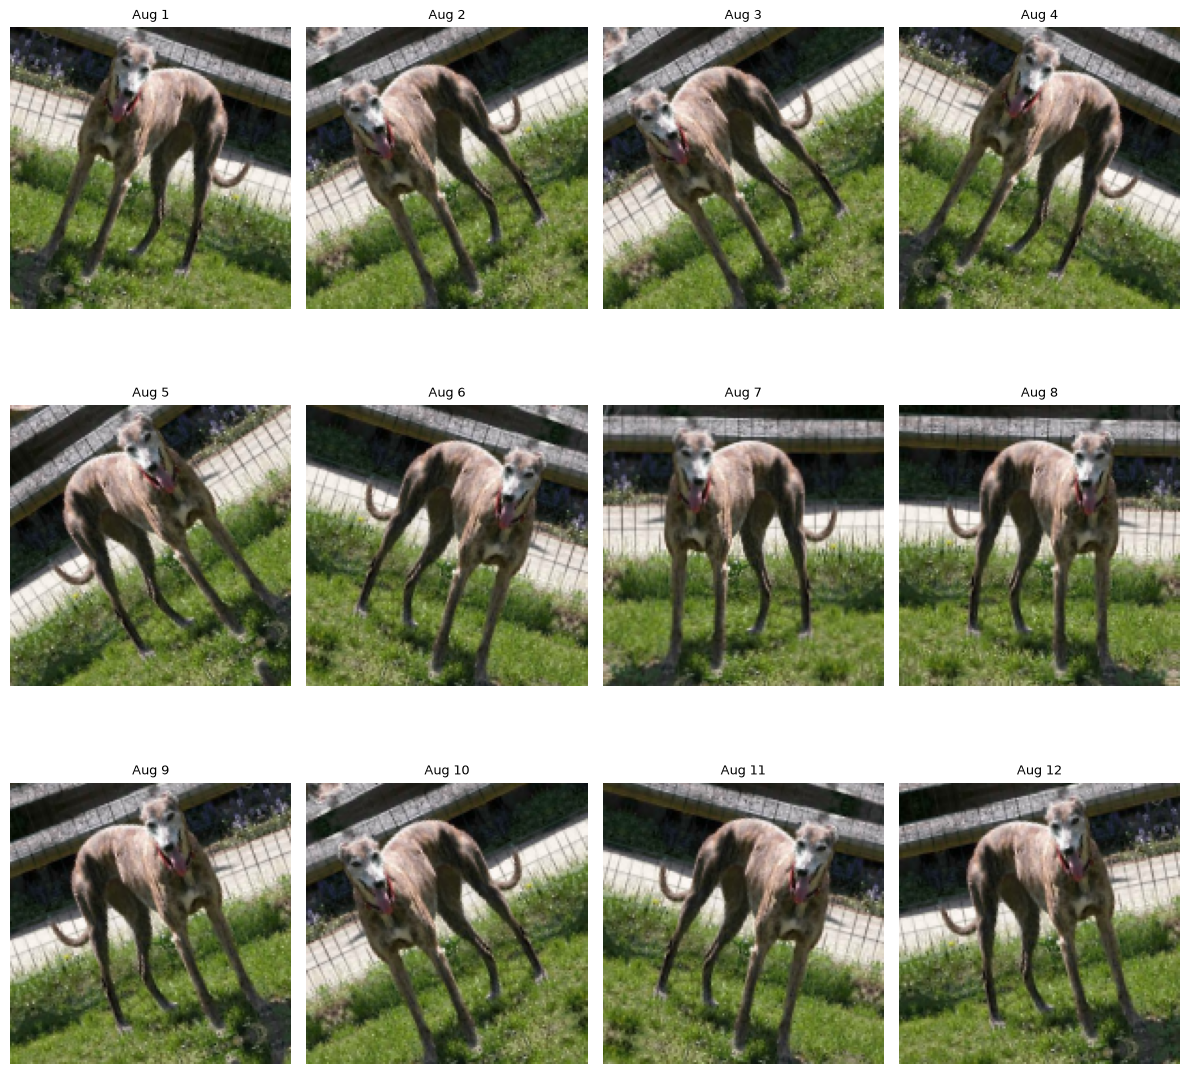

In [21]:
#And now let's take a look at the augmented versions of our selected image
plt.figure(figsize=(12, 12))
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.title(f"Aug {i+1}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Task 2

Your task here is to add other transformations mentioned above(zooming and shearing) and plot the results!
Some transformations may not exist, don't worry, just ignore these transformations.
Add the other two transformations in the layer. REPORT THE RESULTING IMAGES.

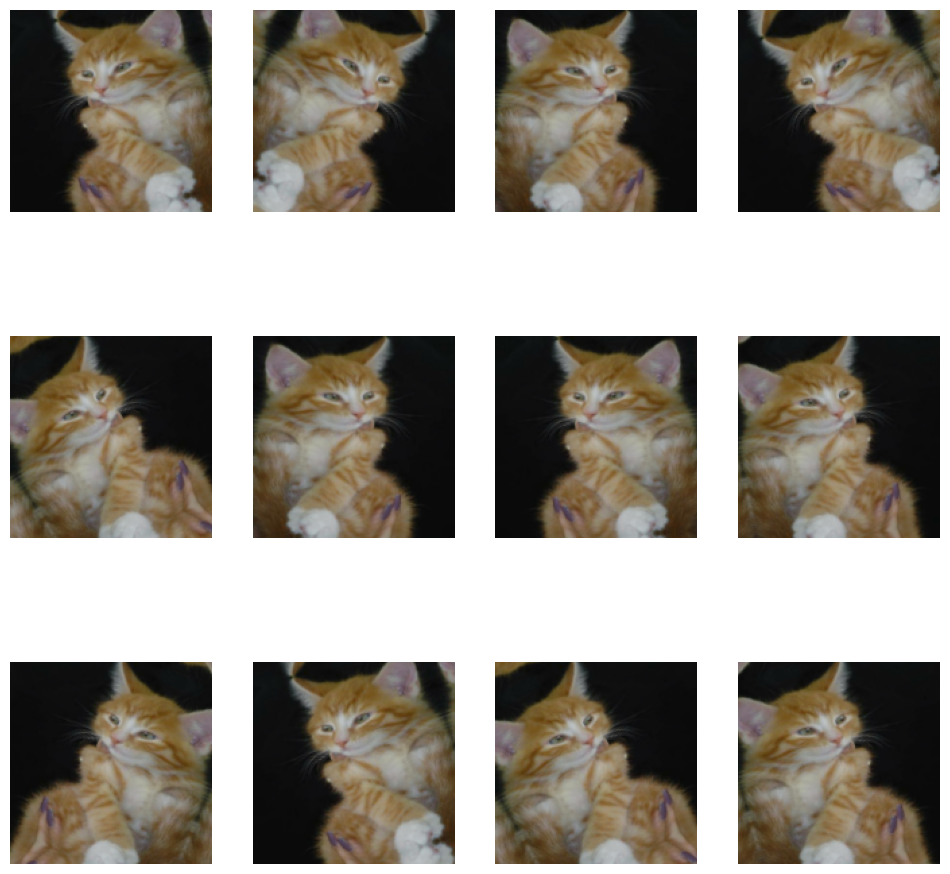

In [22]:
data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
        #Your Code here
        #Your Code here
    ]
)

for images, labels in training_set.take(1):
    plt.figure(figsize=(12, 12))
    first_image = images[0]
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0)
        )
        plt.imshow(augmented_image[0].numpy().astype("int32"))
        plt.axis("off")




## Create a base model from the pre-trained Xception model

Let’s load the model with the weights trained on ImageNet. When that’s done, the desired input shape is defined.

`include_top=False` means that you’re not interested in the last layer of the model. Since models are visualized from bottom to top, that layer is referred to as the top layer. Excluding the top layers is important for feature extraction in our case, since we are not going to train all the parameters of
the model, just the last layer that makes the final prediction.

In [23]:
base_model = keras.applications.Xception(
    weights='imagenet',
    input_shape=(150, 150, 3),
    include_top=False)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Next, freeze the base model layers so that they’re not updated during the training process.

Since many pre-trained models have a `tf.keras.layers.BatchNormalization` layer, it’s important to freeze those layers. Otherwise, the layer mean and variance will be updated, which will destroy what the model has already learned. Let’s freeze all the layers in this case.

In [24]:
base_model.trainable = False

Create the final dense layer

When loading the model, you used `include_top=False` meaning that the final dense layer of the pre-trained model wasn’t included. Now it’s time to define a final output layer for this model.

Let’s start by standardizing the size of the input images.

In [25]:
inputs = keras.Input(shape=(150, 150, 3))

After this, apply the data augmentation.

In [26]:
x = data_augmentation(inputs)

This model expects data in the range of (-1,1) and not (0,1). So, you have to process the data.

Luckily, most pre-trained models provide a function for doing that.

In [27]:
x = tf.keras.applications.xception.preprocess_input(x)

Let’s now define the model as follows:

    ensure that the base model is running in inference mode so that batch normalization layers are not updated during the fine-tuning stage (set `training=False`);
    convert features from the base model to vectors, using `GlobalAveragePooling2D`;
    apply dropout regularization;
    add a final dense layer (when you used `include_top=False,` the final output layer was not included, so you have to define your own).


In [28]:
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

Train the model

You can now train the top layer. Notice that since you’re using a pretrained model, validation accuracy starts at an already high value.

In [29]:
model.compile(optimizer = 'adam',
              loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics = [keras.metrics.BinaryAccuracy()])

model.fit(training_set, epochs=20, validation_data=val_dataset)

Epoch 1/20


/home/haron/anaconda3/envs/ai-ml/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1791025622.210774   14821 cpu_allocator_impl.cc:82] Allocation of 22429696 exceeds 10% of free system memory.
W0000 00:00:1791025622.224650   14821 cpu_allocator_impl.cc:82] Allocation of 42467328 exceeds 10% of free system memory.
W0000 00:00:1791025622.249259   14821 cpu_allocator_impl.cc:82] Allocation of 42467328 exceeds 10% of free system memory.
W0000 00:00:1791025622.249264   14810 cpu_allocator_impl.cc:82] Allocation of 21233664 exceeds 10% of free system memory.
W0000 00:00:1791025622.264985   14821 cpu_allocator_impl.cc:82] Allocation of 84934656 exceeds 10% of free system memory.


63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 849ms/step - binary_accuracy: 0.8855 - loss: 0.2541 - val_binary_accuracy: 0.9560 - val_loss: 0.1027
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 815ms/step - binary_accuracy: 0.9395 - loss: 0.1574 - val_binary_accuracy: 0.9650 - val_loss: 0.0888
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 814ms/step - binary_accuracy: 0.9475 - loss: 0.1220 - val_binary_accuracy: 0.9630 - val_loss: 0.0819
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 817ms/step - binary_accuracy: 0.9575 - loss: 0.1049 - val_binary_accuracy: 0.9640 - val_loss: 0.0790
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 816ms/step - binary_accuracy: 0.9540 - loss: 0.1102 - val_binary_accuracy: 0.9670 - val_loss: 0.0766
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 816ms/step - binary_accuracy: 0.9590 - loss: 0.1038 - val_binary_accuracy: 0.9640 - val_loss: 0.0741
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 815ms/step - binary_accuracy: 0.9685 - loss: 0.0847 - val_binary_accuracy: 0.9700 - val_loss: 0.0722
Epoch 8/20

## Fine-tuning the model further by updating the base model aswell

The model can be improved by unfreezing the base model, and retraining it on a very low learning rate.

You need to monitor this step because the wrong implementation can lead to overfitting. First, unfreeze the base model.

In [30]:
#load the model again as before
#then define the trainable parameter

base_model.trainable = True

After updating the trainable attribute, the model has to be compiled again to implement the change.

In [31]:
model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss=keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=[keras.metrics.BinaryAccuracy()])

To prevent overfitting, let’s monitor training loss via a callback. Keras will stop training when the model doesn’t improve for five consecutive epochs. Let’s also use TensorBoard to monitor loss and accuracy.

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

In [33]:
!rm -rf logs

In [34]:
%reload_ext tensorboard
#%load_ext tensorboard
log_folder = 'logs'
callbacks = [
            EarlyStopping(patience = 5),
            TensorBoard(log_dir=log_folder)
            ]

#EarlyStopping prevents overfitting to some extent, if the error does not improve
#significantly on the validation set for 5 epochs (or even goes up), the training is stopped.

OK, time to retrain the model. When it’s finished, you’ll notice a slight improvement from the previous model.


In [35]:
model.fit(training_set, epochs=15, validation_data=val_dataset, callbacks=callbacks)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 242s 4s/step - binary_accuracy: 0.8675 - loss: 0.3176 - val_binary_accuracy: 0.9650 - val_loss: 0.0913
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 221s 4s/step - binary_accuracy: 0.8915 - loss: 0.2502 - val_binary_accuracy: 0.9660 - val_loss: 0.0985
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 223s 4s/step - binary_accuracy: 0.9075 - loss: 0.2109 - val_binary_accuracy: 0.9660 - val_loss: 0.1014
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - binary_accuracy: 0.9265 - loss: 0.1725 - val_binary_accuracy: 0.9650 - val_loss: 0.1031
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 222s 4s/step - binary_accuracy: 0.9235 - loss: 0.1767 - val_binary_accuracy: 0.9650 - val_loss: 0.0967
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - binary_accuracy: 0.9485 - loss: 0.1360 - val_binary_accuracy: 0.9650 - val_loss: 0.0938


In [ ]:
## If tensorboard freezes you may want to try to kill the process. you need to insert the right process id for this
#!kill PrecessID

In [ ]:
%tensorboard --logdir /content/logs

# Task 3

Your job is now to do a similar table as with the first task. Fine-tune 3 networks with imagenet weights on the CIFAR100 dataset and
report the average performance on the test set. Make sure that
you report the accuracy when finetuning the last layer only as well as
after futher fine tuning the whole base model. Use the same learning rates
as in the example above and make sure that the model input_size matches
the size of the CIFAR100 dataset.

IMPORTANT NOTES:

- We don't use a validation set like in the example, but
split a subset of 20% of the training set and use it as validation during training.
The final test after the training is done on the test set of CIFAR100 you
get when loading the data (See Task 1, when you load the data you get
two tuples: (X_train, y_train), (X_test, y_test)
- You can define this behaviour by simply defining the validation_split=
parameter in the .fit() method, that is, validation_split=0.2
- Since this is a multiclass-classification, you need to change
the metric in the .fit() method to "accuracy" and the loss to "categorical_crossentropy".
- Since we are using tensorboard to monitor the training,
include the learning curves of the 3 networks in your report. It is enough
if you include the learning curves of training the last layer only. You don't
need to include the curves for the final fine-tuning of the whole model.

Example table on test set (PUT THIS IN THE REPORT):

| Network | Accuracy last Layer | Accuracy whole model |
| --- | --- | --- |
| Network 1 | 95% | 97% |
| Network 2 | 90% | 98% |
| Network 3 | 91% | 94% |





# Your pipeline might look like this
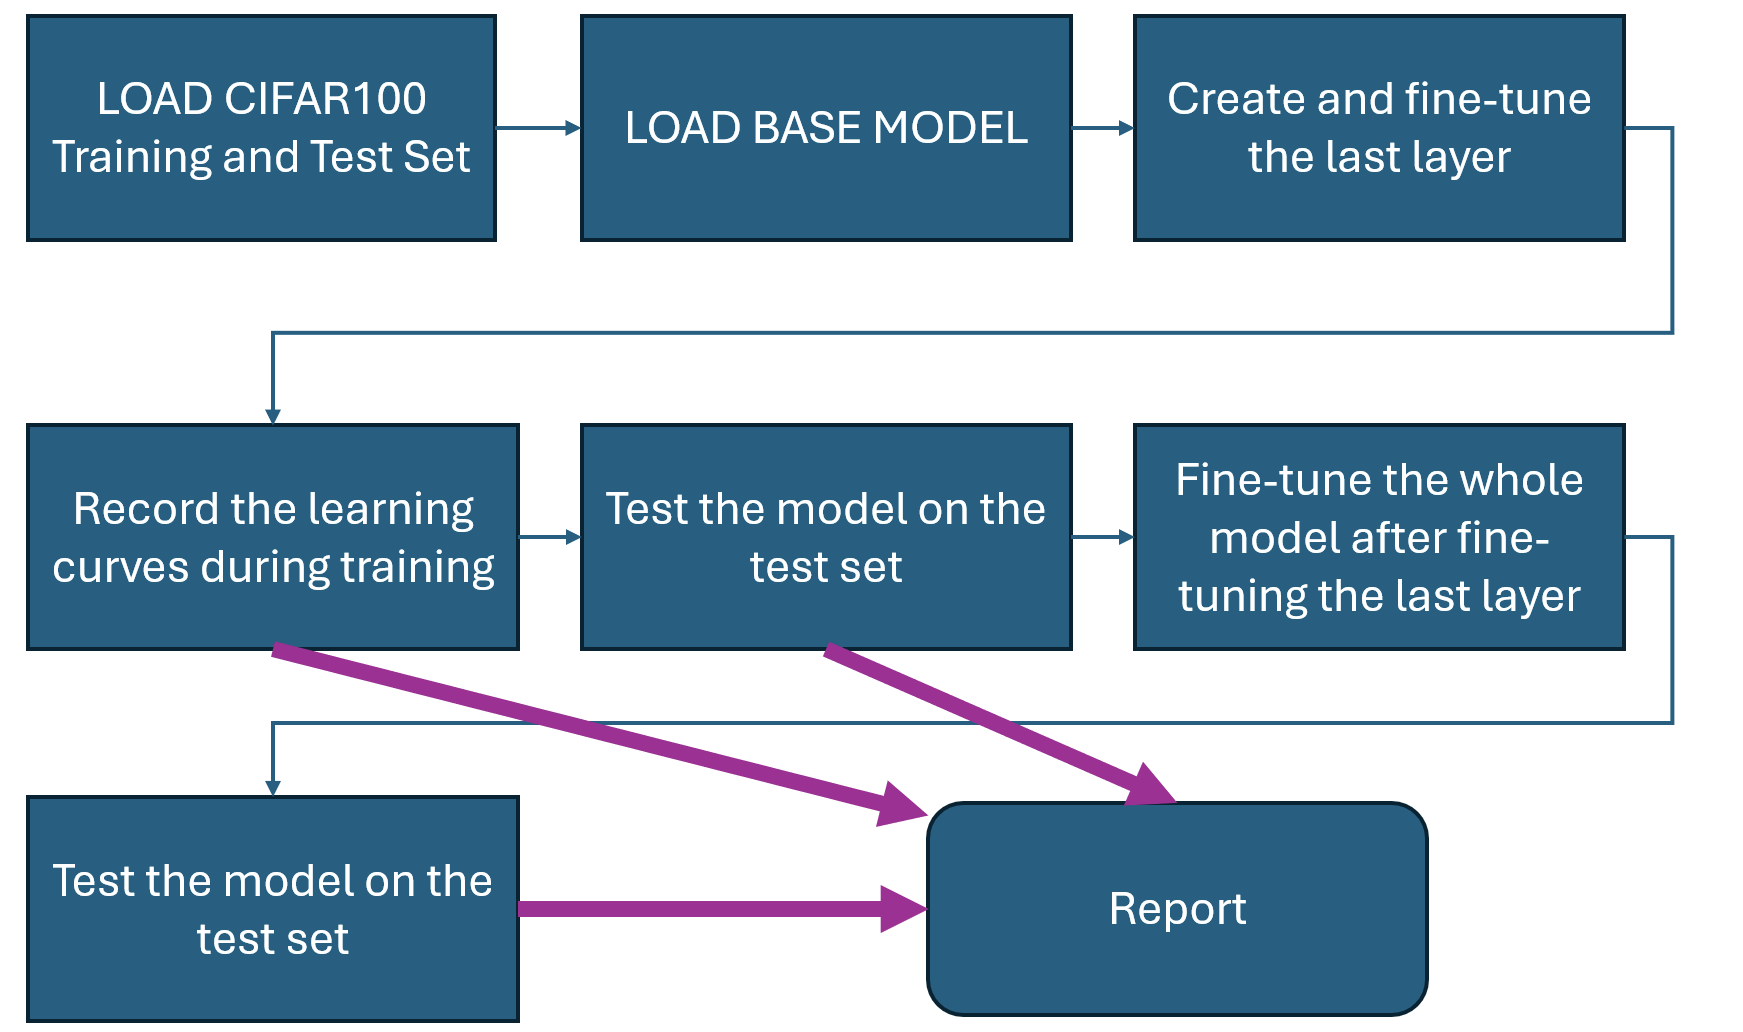

In [ ]:
#Your code Here